# 前言

在人工智能发展的最新浪潮中，大语言模型(Large Language Model，LLM)，以下简称为大模型，已成为通用智能迈向实用化与产业化的关键基石。随着Transformer架构的成熟、算力资源的快速提升以及数据训练范式的不断演进，LLM的应用早已突破传统的问答与对话任务，深入拓展到复杂任务执行、流程控制、工具调用与自主决策等高阶能力的实现之中。

在这一技术背景与需求趋势的交汇点上，智能体系统应运而生。它将LLM的理解与生成能力延展为“感知−认知−执行”一体化的任务执行框架，代表了当前人工智能系统进化的核心方向和未来发展范式。

本书旨在全面系统地讲解如何基于LLM构建智能体系统，聚焦从理论原理到工程实战的全链路技术栈。本书共分13章，涵盖LLM技术基础、Agent核心模块、LangChain框架、LangGraph框架、检索增强生成机制(RAG)、上下文协议(MCP)、多Agent通信（A2A协议）​、扣子低代码平台等关键模块，各章内容概要介绍如下：

第1章从技术演进的视角出发，介绍从专家系统到模型的发展脉络，并剖析智能体系统中的“感知−认知−执行”链条。

第2章详细拆解智能体的核心模块构成与生命周期管理机制，深入解析感知模块、推理规划模块、行动执行模块和记忆系统的协同工作原理。

第3章则聚焦LLM的服务部署与调用方式，详述SaaS与本地模型的部署流程、微调机制、LoRA注入与推理优化策略，为模型落地提供完整技术支持。

第4章介绍LangChain核心组件（LLM接口、Chains、Tools集成、Memory管理）及工具集成、Agent运行机制，涵盖链式逻辑、自定义提示词和动态规划。

第5章聚焦LangGraph编排与任务流管理，探讨其核心概念、与LangChain互补关系、工程化实战案例及与协议层衔接，助力复杂任务处理。

第6章阐述RAG机制原理、文档预处理与向量化，以及基于LangChain的RAG实现，提升智能体检索与生成能力，优化信息处理效率。

第7章系统阐述MCP(Model Context Protocol)协议，提出模型上下文段的结构化表示方法，引入系统提示、工具段、记忆段等组件，实现上下文语义标注、路由控制与动态合并，为多轮对话与任务连续性提供基础支撑。

第8、9章以实践为导向，讲解如何构建具备记忆管理与工具调用能力的单智能体系统，并进一步扩展为支持任务拆分、状态同步、消息调度的多Agent系统。

第10章介绍A2A(Agent-to-Agent)通信协议，定义Agent之间的语义协商语言与消息格式，支持请求−响应、广播−订阅、协商−竞争等多种调度模式，为多智能体系统的信息流转与行为协同提供语义基础。

第11章面向低代码场景，介绍如何利用扣子平台以可视化流程图与自然语言方式快速搭建可用的智能体应用，显著降低Agent系统的开发门槛。

第12、13章结合系统部署、安全加固、性能优化、并发处理与用户交互测试等实际工程问题，展示了一个可部署、可维护、可扩展的智能体系统从“技术原型”走向“产品落地”的完整工程闭环。同时，结合Qwen 3.0与DeepSeek-V1等主流开源模型，深入解析如何进行模型接入、RAG融合、多Agent协作与应用上线，形成一套兼顾工程可行性与产业实战性的开发路径。

本书内容深入浅出、结构严谨、案例翔实，适合希望入门LLM应用开发的初学者、探索Agent开发的工程实践者、构建企业AI平台的技术负责人，也适合作为AI教学或智能体开发团队的技术培训参考书。期待本书能够帮助读者构建一个完整的智能体系统知识体系，掌握大模型落地与Agent应用开发的关键能力，在新时代的AI浪潮中勇立潮头、实现突破。   

                                                                                                            著者
                                                                                                            2025年7月


# 第1章　大模型与智能体技术基础
## 1.1 智能体发展的技术背景
智能体的兴起源于对人工智能从被动响应向主动执行的持续探索，其演化历程伴随着知识系统、规则引擎、深度学习与大模型的阶段性突破。
### 1.1.1 从专家系统到语言模型
专家系统是人工智能早期的重要研究方向，其核心思想是模拟人类专家的知识和推理过程，通过规则库与推理引擎实现对问题的判断、分析与决策，其结构通常包括知识库、推理机、解释器与用户接口等关键组件。

#### 1.专家系统的基本原理
知识库承载了专家所具备的专业知识，通常以如果……那么形式的规则进行编码，规则由知识工程师从实际专家那里收集、整理并维护。

推理机负责在知识库的基础上执行推理操作，常见的方法包括正向链推理与逆向链推理。前者从已知事实出发，逐步推导出结论，后者则从待验证结论出发，回溯推导是否存在支持该结论的规则链。

典型的专家系统的核心模块与信息交互结构如图1-1所示，知识获取模块由知识工程师将领域专家的经验转换为机器可解析的形式，并存入知识库中。形式化的表示通常为规则对或语义网络结构。解释器负责将推理过程中的逻辑路径、结果来源与理由反馈至人机交互界面，提供“why”和“how”的信息，从而增强系统的可解释性与信任度

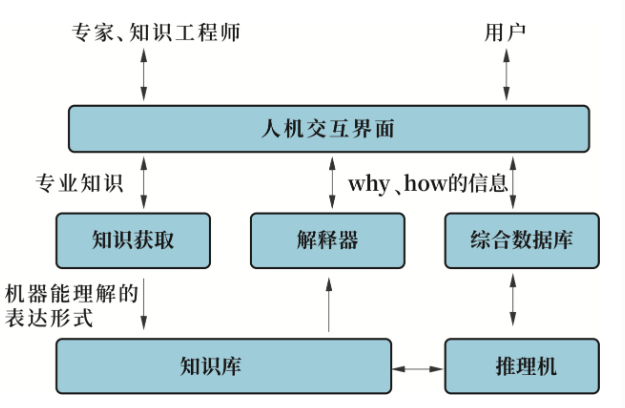

图1-1　专家系统的核心模块与信息交互结构图

综合数据库存储的是运行时数据、事实与用户输入等动态信息。推理机以该数据库为工作记忆，结合知识库中的规则集进行模式匹配、条件验证与推理链构造，从而输出结论或建议。人机交互界面是系统输入与输出的关键桥梁，既接收用户问题，也展示系统推理过程，保障系统的透明性与实用性。

专家系统具备较强的可解释性，输出结论时通常会给出推理路径与依据，适用于结构化明确、规则稳定的封闭领域。然而，其缺点也同样明显，主要包括知识获取困难、规则维护成本高、在面对模糊或开放问题时表现欠佳，缺乏通用性与适应性，尤其在语言理解、视觉感知等复杂任务中难以胜任。

#### 2.统计学习与语言建模的兴起

为解决专家系统的局限，人工智能研究逐步转向数据驱动范式，基于统计学习的方法逐渐取代了符号规则体系。在自然语言处理领域，语言模型成为核心方法之一。最早的语言模型基于n元文法，依赖词频统计构建词序列条件概率分布，尽管可以对短文本进行建模，但在处理长距离依赖与多义歧义问题时效果有限。

随着机器学习的快速发展，神经网络语言模型应运而生。通过引入嵌入向量、隐藏状态与非线性映射函数，模型能够捕捉词语之间的语义关联性。特别是循环神经网络与长短期记忆结构的引入，显著提升了语言模型对上下文的记忆能力，为语言生成、机器翻译、情感分析等任务提供了更强的建模能力。

#### 3.Transformer模型与语言智能体的奠基

标准Transformer编码器结构如图1-2所示，其核心由多头注意力机制与前馈网络组成。输入经过嵌入层后与位置编码相加，形成具备顺序感知能力的表示向量，再通过多头注意力模块进行全局依赖建模。各注意头并行计算不同语义维度下的相关性，结果通过线性投影融合，并与残差连接与层归一化组合形成稳定的特征通路。

接下来，数据经过逐位置独立的前馈网络完成非线性变换，进一步提升表示能力。最终，经过线性变换与归一化后，通过Softmax生成预测概率。整个结构可重复堆叠，形成深层语义建模能力，是现代语言智能体生成能力与推理能力的基础构件。

基于Transformer结构构建的大规模预训练模型，如BERT、GPT、T5等，不仅具备强大的文本生成与理解能力，还表现出一定的推理、归纳与任务迁移能力。随着模型规模从亿级参数扩展至百亿、千亿规模，语言模型已不仅仅是语言处理工具，而逐渐具备了类通用智能的能力，可以通过Prompt（提示词）引导完成摘要、编程、检索、问答、规划等多种任务。

三种基于Transformer架构的变体模型如图1-3所示。标准Transformer包含编码器与解码器两个子模块。编码器利用双向注意力处理输入，解码器通过掩码多头注意力机制防止未来信息泄露，用于序列到序列的建模。GPT采用解码器结构的简化版本，仅保留单向掩码注意力层，支持自回归文本生成，是典型的生成式预训练模型。BERT则完全基于编码器堆叠，通过双向注意力捕捉上下文信息，用于构建深层语义表示，广泛应用于分类、问答与抽取等理解任务。这三种结构定义了预训练语言模型的基本范式，是现代语言智能体系统任务建模与能力构建的理论基础。

这类语言模型逐步承担起语言智能体的角色，能够在开放环境中接收自然语言指令，理解用户意图，并通过语言生成方式完成复杂任务的决策与执行，展现出超越传统专家系统的灵活性与适应性。

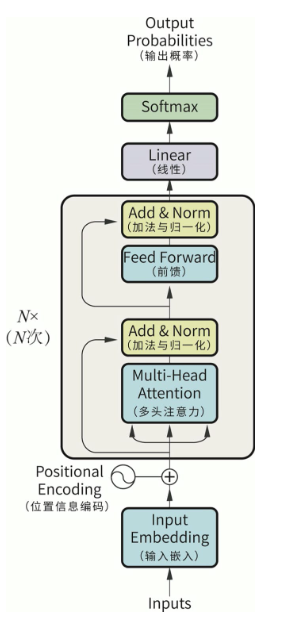

图1-2　Transformer编码器结构及其在语言建模中的计算流程

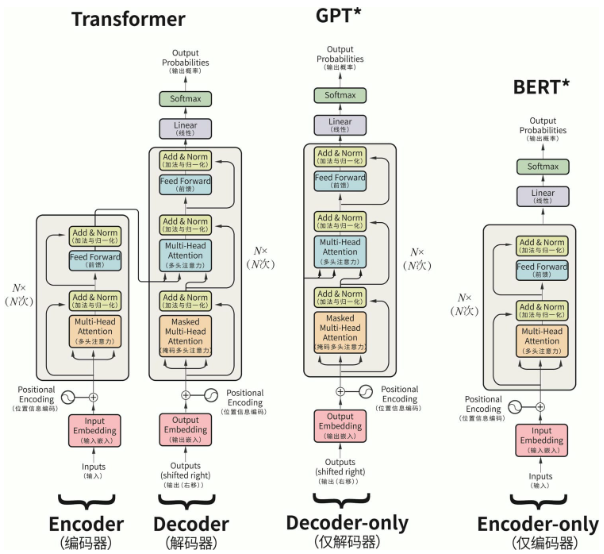

图1-3　Transformer、GPT与BERT结构对比及其模型架构差异

#### 4.范式转移与智能体系统的演化

从专家系统到语言模型的发展过程，实质上是人工智能从符号主义向连接主义，从人工规则向统计学习的根本转变。专家系统强调形式逻辑与可解释性，而现代语言模型则依赖大规模数据与非线性表示，具有更强的泛化能力与任务适应性。

这种范式转移催生了以语言模型为核心的智能体系统。新一代智能体不再依赖预定义的规则集，而是通过上下文建模、Prompt设计、外部工具调用与反馈机制实现任务执行，其结构更加开放，能力更加强大，可适应多领域、多任务的复杂交互场景。

综上所述，从专家系统到语言模型的发展历程，展现了人工智能技术体系的重大跃迁，为构建具备认知、推理与行动能力的智能体系统奠定了理论基础与技术条件，预示着通用人工智能时代的发展方向。

### 1.1.2 感知−认知−执行

感知−认知−执行(Perception-Cognition-Action)模型是构建智能体系统不可或缺的基础结构，在语言智能体架构中，该模型被具体化为语言理解、推理规划与工具调用3个关键能力模块，三者通过上下文结构与任务接口紧密协同，实现智能体从被动应答到主动决策的能力跃升。该机制不仅适用于单一Agent的任务流程，也为多智能体系统中的角色划分与协作设计提供了可扩展的结构模板。

#### 1.感知−认知−执行的基本框架

感知−认知−执行是智能体系统中核心的运行框架，其本质是模拟人类或自然智能体完成信息获取、任务决策与行动反馈的全过程，是支撑智能体自主行为与任务完成的基本逻辑链条，如图1-4所示。在人工智能领域，尤其是在大模型驱动的智能体系统中，这一结构被抽象为多层协同的任务处理体系，每个阶段对应不同类型的计算组件与信息流转机制。

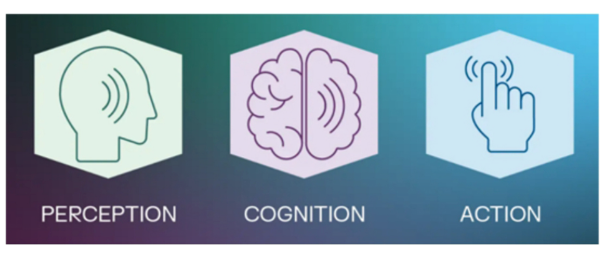

图1-4　感知−认知−执行框架

感知阶段主要负责对外部环境或用户输入进行理解与表征，认知阶段则在理解的基础上进行逻辑推理、任务规划与策略生成，执行阶段根据认知结果完成具体动作，如调用工具、访问数据库或与用户交互。三者之间具有明显的阶段性，但又通过共享上下文与中间状态保持紧密的动态耦合。

#### 2.感知阶段：信息的获取与语言解析

传统系统中，感知通常是指对物理世界的传感器数据进行采集与初步处理，如图像识别、语音转录或温度检测等。而在语言模型驱动的智能体中，感知的主要内容转换为对自然语言输入的理解与语义抽取，即将非结构化的语言表达转换为结构化的意图表示或问题形式。

这一阶段主要包括：
(1)对输入内容的语言解析能力，如句法分析、关键词提取、实体识别。
(2)对用户意图的语义建模能力，如判断请求类型、识别操作对象。
(3)对上下文历史的融合能力，实现多轮对话的上下文连贯理解。

大模型凭借其强大的文本表示能力，能够在这一阶段完成对复杂指令、多语言文本及模糊表达的深度理解，是构建任务驱动型Agent的前提条件。

#### 3.认知阶段：推理规划与行为决策

认知阶段是整个智能体系统的核心部分，涉及信息整合、逻辑推理、策略选择与任务规划等一系列认知计算过程。在这一阶段，智能体不仅要基于当前输入作出判断，还要综合历史信息、任务目标、系统状态以及外部知识进行多层次的分析与抽象。

该阶段可进一步细化为：
(1)意图识别与任务分类：确定请求类型，是查询、生成、控制还是操作。
(2)任务分解与规划：将复杂任务划分为多个子步骤，并确定执行顺序。
(3)工具选择与参数设计：根据任务目标选择合适的工具链并构造输入参数。
(4)回退与错误预判：识别潜在失败路径，构造容错与中断恢复机制。

现代大模型如通义千问Qwen 3.0、GPT-4等具备一定的链式思维与上下文推理能力，在合理设计Prompt与上下文结构的基础上，可以支持有限复杂度的规划与决策操作，是认知阶段能力实现的技术核心。


#### 4.执行阶段：动作调度与工具调用

执行阶段是认知结果的具体实现，承担任务的“最后一公里”落地工作。在传统系统中，执行通常通过调用函数、控制接口或机械部件实现，而在语言智能体中，执行往往表现为工具调用、API接口访问、数据库查询、函数执行等可编程行为。

关键构成包括：
(1)动作调度模块：根据认知输出确定需要调用的工具及其执行顺序。
(2)工具集成接口：将各类工具封装为可调用模块，并规范输入输出格式。
(3)调用反馈管理：处理工具返回结果，包括成功、失败或部分结果处理。
(4)环境状态更新：根据执行结果更新系统状态或用户上下文。

执行阶段不仅需要模型具备语言生成能力，还需依赖工程机制支持外部接口连通，因此通常需要结合LangChain、Function Calling或低代码平台进行落地实现。

#### 5.结构闭环与多轮协同

感知−认知−执行三阶段虽然在逻辑上清晰分离，但在智能体实际运行中常常呈现感知−认知−执行−再感知的闭环结构，即执行结果可能作为新一轮感知输入进入下一轮任务流程。这种循环结构使得智能体具备动态适应与自我修正能力，能够在不确定性环境下持续调整任务策略，提升整体智能表现。

此外，在多轮对话、多步骤任务执行、多Agent协作等场景中，感知−认知−执行链条会跨越多个模块并行展开，此时对上下文状态管理、任务标识追踪与信息流协调提出更高要求，只有构建稳定、统一的上下文传输协议与工具接口标准，才能支撑复杂系统中智能体的协同运行。

### 1.1.3 智能体的系统级结构模型

智能体的系统级结构模型是构建可执行、可扩展、可维护智能系统的基础框架，其核心在于模块化设计、上下文驱动协同与能力层级分布，通过感知、认知、执行、记忆与接口五大模块的有机协作，实现了从自然语言理解到任务完成的完整流程控制。该结构不仅适用于单体Agent的任务系统，也为多智能体协同、异构模型集成与平台级智能系统提供了工程化实施基础。

#### 1.智能体的系统化建模需求

随着大模型的广泛应用与任务复杂度的持续提升，单纯依赖模型调用完成问答或内容生成已难以满足真实场景中的多任务、多步骤、高稳定性需求。语言智能体作为新一代人工智能系统的核心形态，要求在模型能力的基础上构建具备结构化、可控性与模块协同能力的系统框架。因此，构建一套系统级的智能体结构模型，成为智能体工程化部署与多场景落地的前提条件。

系统级智能体模型不仅仅是语言模型的调用封装，更是感知理解、任务规划、行为执行与状态管理等模块的有机协作，是一个面向全流程、多层次的信息处理与响应体系。其构建需要在架构层、组件层与通信层等维度进行系统性设计，确保智能体具备模块独立性、调用通用性与状态可持续性。

#### 2.智能体的核心组成模块

典型的系统级智能体结构通常包括五大核心模块：感知模块、认知模块、执行模块、记忆模块与接口模块，每个模块各司其职，协同工作，构成完整的智能处理链路。

(1)感知模块：负责接收用户输入或外部环境状态，完成自然语言解析、实体识别、意图抽取等任务，是连接输入源与内部认知机制的桥梁。
(2)认知模块：承担主要的信息加工与决策任务，包括问题理解、任务分类、流程规划、工具选择等，是智能体的推理中心。
(3)执行模块：将认知阶段的决策结果转换为具体动作，常表现为工具函数的调用、API接口访问或外部系统控制，是完成实际任务的手脚系统。
(4)记忆模块：存储智能体运行过程中的短期与长期信息，包括用户历史、中间状态、上下文摘要等，是支持多轮交互与状态保持的记忆系统。
(5)接口模块：实现与外部平台、用户界面、数据库及其他智能体的通信桥接，确保系统可嵌入多种运行环境，是智能体感知世界的通道。

一种典型的语言智能体的运行架构如图1-5所示，其核心由Agent模块负责任务解析与行为决策，接收用户输入后，结合系统状态，通过内嵌的感知、推理与执行机制进行处理。Agent可访问数据库查询结构化信息，调用本地文件读取非结构化数据，或接入多模态传感器实现环境感知，通过上下文建模与Prompt编排完成推理规划。

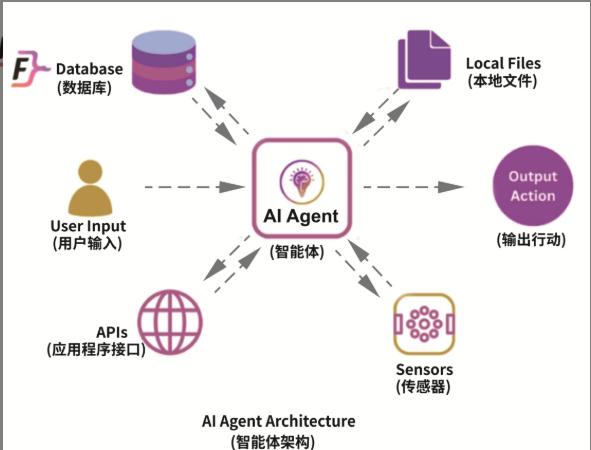

图1-5　AI智能体系统的功能构成与外部接口架构

执行层通过API调用外部服务或控制物理执行器完成任务响应，输出结果可为文本、图像、动作指令等。整个系统支持多通道双向数据流，具备环境适应、自主规划与工具协同能力，是构建复杂任务型AI Agent的基础运行框架。

以上模块通常围绕一个共享的上下文管理系统展开协同，确保信息在模块之间高效流动并被准确调用，是支撑智能体系统稳定运行与可扩展性的基础。

#### 3.模块间的信息流动与协同方式

在系统运行过程中，各模块之间的信息交互基于上下文对象(Context Object)进行统一管理，该上下文结构记录当前任务的输入、用户状态、历史调用记录、中间结果等，是系统级协同的核心信息载体。具体而言：
(1)感知模块将解析后的结构化输入写入上下文。
(2)认知模块从上下文读取用户意图与历史状态，生成行动指令。
(3)执行模块根据指令调用工具，将结果写入上下文。
(4)记忆模块定期将上下文内容进行摘要或分层存储，供后续调用。
(5)接口模块负责上下文与外部环境之间的数据交换与同步。

这种基于上下文驱动的模块协作模式，有利于智能体系统的解耦扩展与过程追踪，也是多智能体系统中信息同步与状态共享的重要支撑机制。

#### 4.智能体系统的分层架构模式

为实现模块功能的清晰划分与系统部署的灵活扩展，智能体系统通常采用分层架构设计，可划分为以下3个层级：

(1)基础模型层：负责底层语言能力的提供，包含大模型的推理服务、Embedding服务、多模态理解模型等。

(2)智能体能力层：以Agent为单位构建任务执行体，包含感知、认知、执行与记忆模块，负责接收任务请求并完成推理与操作流程。

(3)应用与接口层：提供前端交互、系统调用、API封装与多系统协同能力，实现与用户界面或其他平台的集成部署。

这种分层结构使得系统具备良好的模块解耦性与开发可维护性，模型层可以独立升级，能力层支持横向扩展，接口层则可根据场景灵活调整，提高系统的整体稳定性与部署适应性。

#### 5.智能体系统的动态演化机制

现代智能体系统不仅具备静态结构能力，还应具备自适应与演化能力，可在运行中不断学习与优化，主要体现在以下3个方面：

(1)记忆增强与状态沉淀：通过记忆模块对用户行为与交互历史进行建模，实现长期状态的积累与复用。

(2)行为反馈与策略更新：基于任务执行结果自动调整Prompt、工具调用顺序或调用条件，形成自我优化闭环。

(3)模块热插拔与功能迁移：支持动态替换、加载或禁用某些功能模块，使系统具备弹性与可配置能力。

这些演化机制使得智能体不再是静态流程的简单执行器，而逐步演化为具备适应能力的自主系统，具备跨任务、跨场景的泛化应用潜力。

## 1.2 大模型的基本架构

大模型作为智能体系统的认知核心，其架构设计直接决定了语言理解与生成的能力边界。Transformer作为当前主流的大模型基础结构，凭借其自注意力机制与多层堆叠架构，在长距离依赖建模与并行计算效率上取得突破性进展。本节将系统介绍大模型的核心构成与关键机制，重点剖析Transformer的结构原理、编码和解码过程、注意力机制的计算方式以及位置编码的语义作用，为后续智能体系统中的模型能力调度与上下文管理打下结构性认知基础。


### 1.2.1 Transformer结构剖析

Transformer结构作为现代大模型的基础架构，通过自注意力机制、多头注意力、前馈网络、残差连接与位置编码等模块，构建了具备强大上下文建模能力与并行计算优势的神经网络结构。其灵活的编码器−解码器设计不仅适用于语言理解任务，也广泛应用于语言生成、对话系统、多模态交互等场景，是语言智能体系统实现的基础支撑。理解Transformer的结构逻辑是把握大模型行为与智能体能力边界的关键前提。

#### 1.Transformer模型的提出背景

Transformer结构是当前大模型的核心架构，自2017年被提出以来，已成为自然语言处理领域最重要的基础技术之一。其设计初衷是为了解决传统循环神经网络在序列建模中存在的长期依赖问题与训练效率瓶颈。相比于RNN与LSTM，Transformer完全抛弃了时间步迭代结构，采用全并行的自注意力机制，使得模型在序列建模中兼顾了建模能力与计算效率，成为后续BERT、GPT、T5等主流模型的基础结构。

Transformer的核心在于其堆叠式的编码器−解码器架构与全局注意力机制，能够实现对输入序列中任意位置信息的建模，是支持语言理解与生成任务的关键机制，其架构的模块化、层级化特点也极大地增强了系统的可扩展性，便于与其他智能体组件协同构建复杂任务流程。

#### 2.模型整体结构组成

标准的Transformer架构由编码器(Encoder)与解码器(Decoder)两部分构成，分别用于处理输入信息与生成输出结果，整个模型结构呈现对称堆叠的层级设计，每一层均由多个子模块组成，具有高度可复用性与并行计算能力。

(1)编码器部分主要负责接收输入序列，通过多层自注意力机制与前馈网络提取上下文表示，输出每个位置对应的上下文特征。

(2)解码器部分则以编码器输出为条件，通过掩码自注意力与交叉注意力机制生成目标序列，是支持序列生成与翻译等任务的关键。

Transformer模型中的自注意力机制的核心计算过程如图1-6所示。输入序列首先通过嵌入层转换为固定维度向量，再映射为查询、键和值3组向量，经由线性变换生成Q、K、V矩阵。注意力权重由查询向量与键向量的点积计算得到，经缩放后与掩码矩阵相加，用以屏蔽无效位置，再输入Softmax函数生成归一化的注意力分布。

该分布用于加权求和值向量V，输出聚合后的上下文表示。整个过程实现了模型对不同位置信息的动态关注，具备全局依赖建模能力，是Transformer得以捕捉长程依赖并生成语义一致输出的核心算子，广泛应用于语言建模、问答系统与智能体行为控制中。

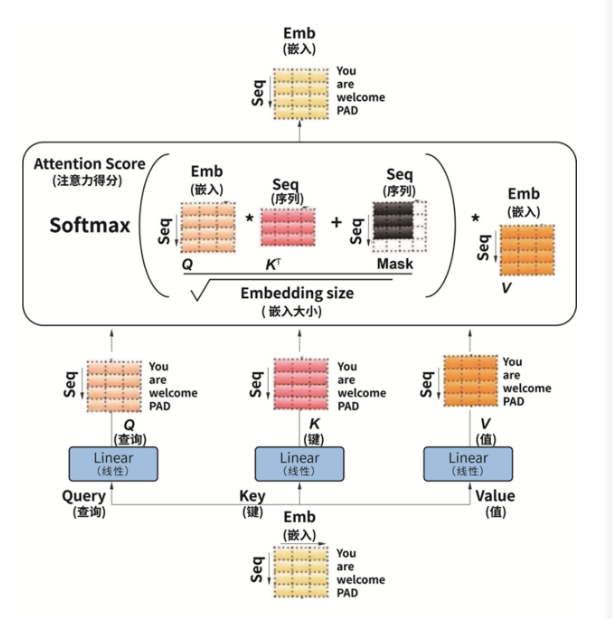

图1-6　Transformer模型中的注意力机制的计算流程图

在实际的大模型中，如GPT系列，通常仅保留解码器结构用于单向生成，而BERT则仅使用编码器结构进行双向理解，结构选择取决于具体任务需求

#### 3.自注意力机制的作用与计算逻辑

Transformer架构的核心机制是自注意力(Self-Attention)，该机制允许模型在处理某个位置的词时，充分考虑序列中其他所有位置的词语信息，从而建立全局的上下文关联关系。这一特性在语言建模中尤为重要，有助于捕捉长距离依赖与语义一致性。

自注意力机制的计算流程本质上是一个加权平均过程，对于输入序列中的每个词向量，计算其与其他词向量之间的相似度，然后根据相似度分配注意力权重，对所有词向量进行加权求和，最终得到该位置的上下文表示。通过这种方式，模型在每一层都能动态重构序列的语义表示，以适应不同任务对上下文理解的需求。

此外，Transformer中的注意力机制通常采用多头注意力(Multi-Head Attention)结构，将注意力计算拆分为多个子空间并行进行，使模型能够从不同角度捕捉语义关系，提升表达能力。

#### 4.前馈网络与残差连接

在每一个Transformer层中，除了自注意力子模块外，还包括一个前馈神经网络(Feed-Forward Network)。该网络作用于每个位置上的表示向量，进一步提升模型的非线性表达能力，通常由两层全连接结构组成，配以激活函数与Dropout（随机失活）操作。

为了加速训练收敛并稳定深层网络的表示能力，Transformer在每个子模块的输入输出之间引入残差连接(Residual Connection)与层归一化(Layer Normalization)，确保在多层堆叠结构下，信息能够顺利传递，避免梯度消失或爆炸问题。这一设计显著提升了模型的深层建模能力与训练稳定性，是Transformer成功的关键工程细节。

#### 5.位置编码机制与顺序建模

由于Transformer不具备序列结构的递归特性，模型本身无法捕捉输入序列中各词的位置信息，因此需显式引入位置编码(Positional Encoding)机制，向输入的词向量中加入位置信息，以便模型感知顺序关系。

常见的实现方式包括固定位置编码与可学习位置编码两种。固定位置编码通过正弦与余弦函数构造各位置的向量表示，具有良好的周期性与可泛化能力；可学习位置编码则将位置向量作为参数在训练过程中学习，灵活性更强。无论采用何种方式，位置编码的本质目的都是在无序输入中注入位置信息，使模型能处理文本中的语序逻辑。

#### 6.堆叠结构与深层表达

Transformer通过将上述模块按顺序堆叠构建多层网络，每一层都会在原始表示上进一步提取更深层次的语义特征，随着层数加深，模型可以逐渐捕捉从词汇层、句法层到语义层的多层次信息，支持复杂语言任务的建模需求。

典型的Transformer序列到序列架构如图1-7所示，其左侧编码器堆叠多层模块，每层包含多头注意力与前馈网络，逐层抽取输入句子的语义特征并构建深层表达。每个词嵌入后通过残差连接与层归一化机制在各层间传递，使模型能够捕捉多粒度、多层次的语言表示。

右侧解码器在每一步生成过程中，结合先前已生成的输出与来自编码器的全局上下文信息，通过掩码机制保证自回归生成特性。整套结构支持源语言到目标语言的高质量转换，是机器翻译、摘要生成等语言智能体任务的基础算子设计。

深层堆叠结构的设计，使得Transformer在面对多语言翻译、文本生成、长文理解等任务时具备极强的表达能力与泛化能力，同时也为后续构建大型预训练模型提供了灵活的参数扩展空间。

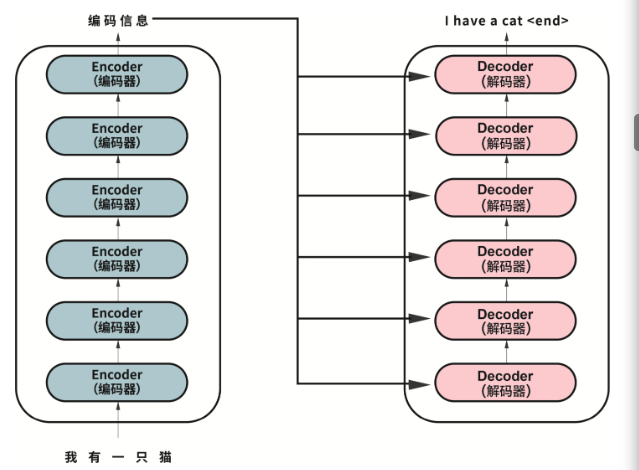

图1-7　基于Transformer的编码−解码翻译结构图


### 1.2.2 编码器与解码器机制

编码器与解码器机制是构建语言理解与生成系统的核心结构，在Transformer架构中实现了结构清晰、效率优越的信息处理链条。编码器侧重于全局语义建模，解码器则侧重于条件文本生成，两者通过注意力机制高效协同，为大模型驱动的智能体系统提供了稳定、可扩展的架构基础。在智能体任务中，编码器−解码器结构不仅支撑语言理解与输出，也构成工具调用、任务规划与多模态协同的底层技术核心。

#### 1.编码器−解码器架构的理论基础

编码器与解码器机制是序列到序列学习(Sequence-to-Sequence，Seq2Seq)模型的核心结构，最早应用于神经机器翻译任务，用于将输入序列映射为语义表示，再生成与其相应的输出序列。在Transformer中，这一机制被进一步拓展为多层堆叠、全注意力结构，显著提升了建模能力与训练效率。编码器负责对输入序列进行全局语义建模，提取信息密集的上下文表示；解码器则利用这些表示生成目标输出序列，是语言理解与生成系统的基础框架。

在现代大模型中，虽然部分模型仅保留其中一个模块（如BERT只使用编码器、GPT只保留解码器）​，但完整的编码器−解码器结构仍是构建具有通用语言理解与生成能力系统的理论源点，其模块划分清晰、功能协同紧密，成为多任务建模与智能体系统构建的重要结构依据。

#### 2.编码器结构与处理流程

编码器的主要任务是接收输入文本序列，将其转换为具有语义表示能力的上下文向量序列，其内部由多个相同结构的编码层堆叠而成，每一层都包含两个子模块：多头自注意力机制与前馈神经网络。

在处理过程中，输入的每个词首先被映射为固定维度的词向量，并添加位置编码用于表征词在序列中的位置信息。随后，自注意力机制计算每个词与序列中其他词的相对关系，从而得到每个位置的上下文加权表示。该机制使模型能够捕捉长距离依赖与全局结构，有效解决传统RNN存在的记忆瓶颈问题。前馈神经网络则负责在每个位置上进行非线性变换，进一步提升语义抽象能力。

在层与层之间，使用残差连接与层归一化以保持信息流动与梯度稳定。最终，编码器输出的每个位置的表示不仅包含该词本身的信息，还融合了与其他位置的语义关联，形成了具备全局上下文感知能力的表示序列，可供后续解码阶段引用。

#### 3.解码器结构与生成机制

解码器的核心任务是基于编码器输出的上下文表示与已生成的目标序列，逐步预测并生成后续词语，其结构同样由多层堆叠组成，但每层包括3个子模块：掩码自注意力机制、编码器−解码器注意力机制与前馈神经网络。

掩码自注意力机制负责处理目标序列的已有部分，为了防止模型在训练阶段窥视未来的输出信息，采用下三角掩码矩阵控制注意力计算，使得每个位置只能关注当前及之前的词语，这种机制确保了解码过程的自回归特性。第二个模块，即编码器−解码器注意力机制，则用于引入编码器的上下文信息，使解码器能够结合输入语义进行输出预测，是实现条件生成与语言对齐的关键模块。第三部分的前馈神经网络与编码器中相同，用于增强表示能力。

在具体生成时，解码器通常采用自回归方式，从起始标记开始，逐步生成一个词，更新输入序列后再生成下一个词，直到生成终止标记或达到最大长度。该机制可用于机器翻译、文本摘要、问答生成等任务，支持条件下的序列建模。

#### 4.编码器与解码器之间的交互关系

编码器与解码器之间通过上下文向量传递机制进行信息交互，编码器输出的每个位置表示被作为解码器注意力机制中的键与值，解码器在生成每个目标词时，根据当前生成状态计算对输入序列中各位置的注意力权重，动态聚合编码器输出，从而实现源语言与目标语言之间的语义映射。

这一设计使得模型能够灵活地对输入信息进行选择性关注，实现更精准的翻译、摘要与内容重构。同时，编码器输出可并行处理整个输入序列，而解码器在训练时可通过并行解码优化效率，在推理时保持逐词生成，兼顾性能与控制能力。

#### 5.模型结构的变体与演化

虽然原始Transformer包含完整的编码器与解码器结构，但在后续应用中，依据任务需求，模型结构也出现了多种变体：

(1)编码器结构独立使用：如BERT模型专注于文本理解，仅使用双向编码器进行上下文建模，适合用于分类、问答、信息抽取等任务。

(2)解码器结构独立使用：如GPT模型采用单向解码器结构进行文本生成，自回归机制确保语言连贯性，是当前主流的大模型架构。

(3)Encoder-Decoder结构融合使用：如T5模型结合两者的优势，适用于翻译、摘要与统一文本任务建模。

此外，近年来的多模态大模型也在编码器与解码器中引入图像、语音、视频等跨模态输入，形成更加复杂的信息交互结构，进一步拓展了语言模型的应用边界。

### 1.2.3 注意力机制与多头注意力

注意力机制是现代语言模型中最具代表性的建模技术，其通过动态分配注意力权重，实现了对信息关系的全局建模与局部聚焦，尤其在Transformer中发展为多头注意力机制，显著增强了模型的表达能力与任务适应性。该机制不仅提升了语言理解与生成的效果，也为智能体系统中复杂任务的感知、认知与协作提供了理论支撑与工程基础，是构建通用智能体能力体系的关键组件。

#### 1.注意力机制的提出背景

在自然语言处理与序列建模任务中，不同词语之间往往存在复杂的依赖关系，尤其是长距离依赖，传统的循环神经网络结构在处理这类关系时常面临信息遗忘与梯度消失等问题。为解决这一瓶颈，注意力机制应运而生，其核心思想是模拟人类在阅读或处理信息时的聚焦行为，即在众多信息片段中分配不同的关注度，重点关注与当前任务相关的信息部分，从而提升整体表达能力。

最初的注意力机制应用于神经机器翻译，在源语言与目标语言之间建立对齐关系，随后被广泛应用于图像处理、语音识别、文本生成等任务，尤其在Transformer结构中成为信息交互的核心机制，取代了传统的递归结构，构建了完全基于注意力的信息处理架构。

#### 2.注意力机制的核心思想

注意力机制通过为输入序列中的每个元素计算其与其他元素之间的相关性或重要程度，从而动态地为每个位置生成加权表示。这一过程包含3个关键要素：查询、键和值。查询表示当前处理的目标位置，键表示所有可被关注的参考位置，值则为每个位置的原始信息表示。最终的输出是所有值向量的加权和，权重由查询与键之间的相关性函数决定。

这种机制的优势在于，可以捕捉序列中任意两个位置之间的相互关系，而无须依赖固定顺序的信息传递路径，极大地增强了模型的建模灵活性与效率，同时也为上下文建模提供了更加精细的控制手段，适应多种语言现象，如主谓一致、同义替换与语义指代等。

#### 3.自注意力机制与序列建模

自注意力机制是注意力机制的一种特化形式，其查询、键和值均来自同一输入序列，允许模型在每一层中捕捉序列内各位置之间的相互依赖关系。在自注意力机制中，每个位置的表示不仅包含自身的信息，也融合了与其他位置之间的语义关联，形成一种全局感知的动态表示方式。

在Transformer中，自注意力机制被广泛应用于编码器与解码器模块的各个层级，通过并行计算与向量化操作实现高效的上下文建模，尤其在处理长文本、复杂语义结构与多轮对话等任务中展现出强大的能力。

#### 4.多头注意力机制的结构设计

尽管单一的注意力机制已经具备一定的建模能力，但在实际任务中，不同的语义关系可能需要在不同的子空间中进行建模。为此，Transformer引入了多头注意力机制，将注意力计算过程拆分为多个头，每个头在不同的低维空间中独立学习注意力分布。

缩放点积注意力机制和多头注意力结构如图1-8所示，通过将查询向量与键向量计算点积后进行缩放，再经Softmax归一化得到注意力分布，用以加权值向量，从而实现对不同位置信息的动态聚焦。该结构有效解决了输入长度变长时点积结果过大导致梯度不稳定的问题，是Transformer中注意力计算的核心算子。

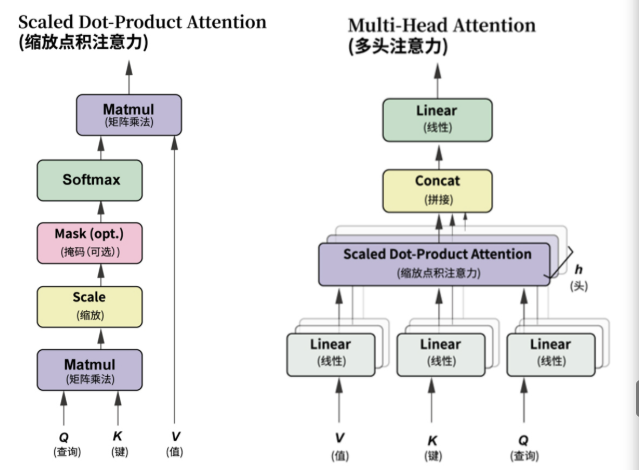

图1-8　多头注意力机制与缩放点积注意力结构图

右侧为多头注意力结构，通过将输入的查询、键、值分别映射为多个子空间，独立执行多组注意力计算，最后将所有注意头的结果拼接并映射回统一空间，从而捕捉不同子空间下的特征表示，增强模型对上下文中多语义维度的理解能力，是实现深层语言建模与多粒度信息融合的关键机制。

具体而言，输入向量被投影为多个子空间，在每个头中分别执行独立的注意力计算过程，然后将各头的输出进行拼接并投影回原始空间，这一机制相当于让模型从多个视角同时建模语义关系，从而提升表达的多样性与细粒度特征感知能力。

多头注意力机制的优势在于：

(1)能够捕捉多类型的语义依赖，如词法关系、句法结构与上下文检索。

(2)提高模型的容量与表达灵活性，避免单一注意力通道的信息瓶颈。

(3)支持大规模参数扩展，有利于预训练模型的性能提升。

在实践中，多头数的设定通常依据模型参数规模、计算资源与任务复杂度进行权衡，是大模型性能调优的重要超参数之一。

#### 5.注意力机制在智能体系统中的作用

在智能体系统中，注意力机制不仅是模型构建的底层基础，也直接影响智能体对信息的感知范围与响应质量。通过注意力机制，模型能够对输入内容中的关键信息进行有效聚焦，从而实现对用户指令的准确理解与任务目标的合理推理，避免信息遗漏或误解。

在复杂任务如多轮对话、任务分解、模态融合等场景中，注意力机制还可用于构建跨步骤、跨模态的信息桥梁，支持Agent在感知与认知过程中对信息进行动态加权与聚焦选择，为智能体系统提供了高度灵活的认知框架与执行依据。

此外，在多Agent协作任务中，注意力机制还可用于构建信息交互策略，如跨Agent注意力对齐、多Agent记忆共享与角色分工引导等，提升系统级协同能力。

### 1.2.4 位置编码与上下文建模

位置编码机制解决了Transformer在处理序列任务时对顺序缺失的问题，是构建大模型上下文建模能力的基础手段。通过结合绝对位置、相对位置与高级扩展策略，位置编码不断演化以适应更长、更复杂的文本建模需求。在语言智能体系统中，位置编码不仅服务于语言模型本身，也深度嵌入对话流程、任务调度与多模块协同中，是构建高质量智能行为链条的核心机制之一。

#### 1.Transformer结构中的位置问题

Transformer模型虽然在注意力机制与并行计算方面带来了巨大优势，但由于其结构不再具备递归或卷积特性，因此在原始设计中完全丧失了对序列中位置信息的感知能力。与传统循环神经网络通过时间步传递维持顺序不同，Transformer对输入的词向量是无序处理的，若无额外机制辅助，模型将无法判断词语在句子中的前后关系，严重影响语言建模能力与语义理解效果。

为解决这一问题，Transformer引入了位置编码(Positional Encoding)机制，通过在词向量中融合位置信息，使模型能够识别序列中各个词的顺序结构，并在注意力计算中综合考虑位置与语义的双重依赖，是构建上下文感知能力的关键基础。

#### 2.位置编码的基本原理

位置编码的核心目标是为输入序列中的每个词分配一个对应的位置向量，再将该向量与原始词向量相加或拼接，从而形成既包含词义信息又包含位置信息的综合表示，使得注意力机制能够在建模词语之间的关系时考虑其在序列中的相对位置或绝对位置。

常见的位置编码方式主要包括两类：固定位置编码与可学习位置编码。固定位置编码通常采用正弦和余弦函数，以不同频率为每个位置生成具有周期性与层级差异的编码向量，该方法具有良好的可解释性与序列泛化能力；而可学习位置编码则将每个位置的编码向量作为模型参数，在训练过程中与其他权重一同更新，具备更强的适应性与表现力，尤其适用于固定窗口长度的应用场景。

Transformer模型输入嵌入的构建方式如图1-9所示，通过将词元嵌入、段落嵌入与位置嵌入三者相加，形成具备语义、句子归属与位置信息的统一输入表示。Token（词元）嵌入用于表示具体词或子词的语义，Segment嵌入用于区分句子A与句子B，常见于双句输入任务，如问答或句对匹配。

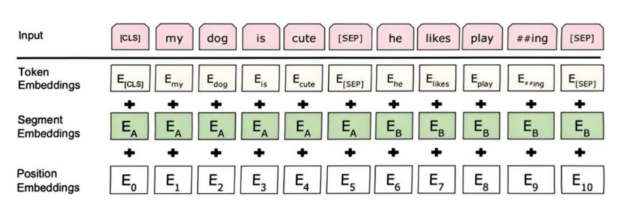

图1-9　Transformer输入表示的三重嵌入结构图

位置编码用于引入序列中词元的相对位置或绝对位置信息，使模型在全并行结构中仍具备序列顺序感。该位置嵌入既可采用固定函数生成，也可通过训练获得，最终三者相加后的向量进入Transformer网络，这是模型理解上下文结构与语序依赖的基础。

此外，近年来还发展出相对位置编码机制，不仅考虑某个词自身的位置，还引入其与目标词之间的相对位置信息，在多头注意力机制中进一步提升了对序列结构的建模能力，显著优化了对长文本、重复结构与嵌套语义的处理效果。

#### 3.上下文建模的技术内涵

上下文建模是指模型在处理某个词语时，能够充分考虑其前后周围词语所携带的信息，从而形成对当前词语在句子中的真实语义理解。上下文信息不仅包括邻近词的语义线索，也包含远距离依赖、主谓关系、句法层级、指代关联等复杂结构

在传统语言模型中，上下文建模受限于窗口大小、记忆深度与信息传递路径，难以准确捕捉长距离依赖。Transformer通过自注意力机制实现任意位置之间的信息直接交互，打破了传统结构对上下文建模的限制，但其能否有效利用上下文，仍然严重依赖于位置编码所提供的顺序信息。

在上下文建模中，位置编码的作用不仅体现在输入层对位置感知的引导，也影响每一层注意力机制的权重分配方式，使模型能够知道当前词应该关注哪些历史或未来词语，这对指代消解、语义一致性判断与任务执行链路构建具有重要意义。

#### 4.长序列与位置编码的扩展机制

随着大模型向更长上下文建模能力的方向发展，传统的位置编码方式在面对上千甚至上万个Token的序列时逐渐显现出表示能力与计算效率的瓶颈问题。为此，研究者提出了多种扩展型位置编码机制，以支持更长文本、更高精度的上下文建模。其中包括：

(1)旋转位置编码(RoPE)：通过在位置编码中引入旋转操作，使得位置信息可以在向量空间中通过角度变换表达，增强了位置表示的连续性与计算稳定性。

(2)可插拔位置编码(ALiBi)：直接在注意力得分中注入位置偏移量，无须额外位置向量，提升模型在推理阶段对未知长度文本的泛化能力。

(3)稀疏注意力与分块位置处理：在处理超长文本时，将序列切分为多个块，引入局部与全局位置编码策略，提升整体计算效率与建模灵活性。

这些机制不断优化位置编码与上下文建模的配合方式，使得大模型具备处理长文档、多轮对话与跨段落推理任务的能力，拓展了智能体系统的应用边界。

#### 5.位置编码在智能体中的应用意义

在语言智能体系统中，位置编码不仅用于基础模型的上下文建模，更是支撑多轮对话状态追踪、复杂任务流程控制与提示词调度等功能的重要技术支点。通过精确标定输入中各段落、命令、变量的位置信息，智能体可以构建任务执行的逻辑结构，从而完成分步任务解析、历史状态检索与工具调用参数绑定等复杂操作。

例如，在多Agent系统中，不同智能体可能处理同一输入序列的不同片段，位置编码机制可用于明确任务段的边界与优先级，避免信息混淆；在工具调用链中，通过明确提示词中参数与说明之间的相对位置关系，提升大模型调用函数的准确性与稳定性。

此外，位置编码还在记忆系统中发挥重要作用，帮助模型识别历史信息在时间轴上的顺序，构建更稳定的任务上下文与对话逻辑，有助于智能体实现跨轮次的连续性决策与行为一致性控制。

## 1.3 大模型能力边界与应用接口

语言模型虽具备强大的语言生成与理解能力，但其在实际应用中仍存在上下文长度限制、推理深度不足、内容控制困难等能力边界。此外，模型的调用能力取决于所提供的API接口设计与输入输出结构约定。本节将围绕模型能力的边界特征、提示词工程的基本策略、输入窗口的管理方式以及多模态能力的接入机制进行系统阐述，帮助厘清模型能力发挥的前提条件与接口控制方式，为智能体系统中模型能力的高效调度提供理论依据。

### 1.3.1 通用能力与推理能力

通用能力与推理能力共同构成了大语言模型的核心智能范式，前者注重语言形式与表达规范，后者强调任务逻辑与认知控制，在智能体系统中分别承担信息输入输出与任务规划执行的核心职能。构建高质量智能体，需要在系统架构中明确两者的能力边界与调度机制，既要保障语言交互的通畅自然，也要推动认知过程的逻辑严密，为复杂任务的顺利执行提供稳定的能力支撑。

#### 1.大语言模型能力的分类

大语言模型具备广泛的通用能力，在语言生成、理解、翻译、摘要等任务中展现出近似人类水平的表现。然而，这些能力并非单一维度可以涵盖，而是在不同认知层次上形成互补关系，通常可从通用语言能力与推理能力两个维度加以划分。前者关注对语言模式的学习与应用，强调语法正确性、语义连贯性与语言表达的自然性；后者则聚焦于在复杂问题中进行逻辑判断、条件分析与多步推导，侧重任务完成过程中的思维链构建与目标导向行为的生成。

智能体系统在构建过程中，既需要语言模型具备处理各种自然语言输入的基础能力，也依赖其推理能力完成多步骤决策、规则匹配与因果判断等高阶任务，因此理解两者之间的区别与交集，是设计Agent行为策略与任务流程的前提条件。

#### 2.语言能力

通用能力是大语言模型最基础也是最广泛的能力范畴，主要来源于大规模文本语料的预训练过程，通过海量句子对模型进行语言模式的学习，使其能够掌握词语搭配、句法结构、语义组织与文本逻辑等语言规律。这种能力在以下几个方面表现尤为显著：

(1)语言理解能力：包括词义辨析、句法结构识别、文本摘要、问答匹配等任务，模型可以通过上下文关系判断词语用法、抽取关键信息或识别语义重心。

(2)语言生成能力：能够在指定的上下文或指令下生成连贯、语法正确的自然语言文本，广泛应用于续写、改写、对话生成与文案创作等。

(3)语言风格与语域控制：通过Prompt引导，模型可以生成符合特定语气、文体或行业术语的文本内容，实现对生成风格的粗粒度调控。

(4)多语言处理能力：具备一定程度的跨语言通用性，可在不同语种之间进行翻译、对齐或语义映射，提升语言智能体的跨文化适应能力。

用语言能力主要反映了模型对语言本身的学习与运用，表现为面向文本特征的模式识别与生成再现，属于大模型的基础服务能力层，是绝大多数智能体对话、交互与表达的支撑根基。

#### 3.推理能力

推理能力是大模型能否胜任复杂任务的关键标志，其本质是在语言表达中实现信息的加工、逻辑的组织与结论的导出。推理不仅要求模型理解输入所包含的显性信息，还要具备隐含关系挖掘、条件判断与多步决策能力，通常包括以下几个方面：

(1)事实推理与常识推理：模型基于训练语料中学习到的世界知识与事实规则，能够判断命题是否合理、两个陈述是否一致，或完成知识补全。

(2)条件推理与假设验证：能够根据如果……那么……结构，模拟条件成立或不成立时的推导路径，是任务规划与流程判断的重要基础。

(3)算术与逻辑推理：涉及对数值、符号或结构化信息的分析与处理，如解决数学题、逻辑谜题或图结构问题。

(4)多步思维链建构：在面对复杂问题时，能够生成中间步骤，逐步推进推理过程，提升生成内容的合理性与可验证性。

推理能力往往不是通过模型单次响应直接体现的，而是依赖于对上下文的长期建模与中间步骤的显式生成，因此需要配合链式提示设计、多轮交互机制或外部记忆支持才能充分发挥。推理能力的强弱决定了模型能否胜任真实世界中的复杂任务，是智能体系统高阶认知行为的实现基础。

#### 4.通用能力

在实际应用中，通用能力与推理能力并非对立存在，而是共同构成语言模型综合智能的两个维度。通用能力是基础，确保输入理解正确、输出表达自然，推理能力是延伸，使模型具备对任务目标的逻辑达成路径构建能力。

例如，在一个问答智能体中，通用能力可帮助识别用户问题并组织回答语言，而推理能力则需要判断问题中的隐含条件、调用外部工具获取信息或构建逻辑链条完成任务。两者的融合使得智能体不仅能看懂和说清，更能想清楚与做正确。
